# N3 Router/Wrapper 테스트 노트북

이 노트북은 primitive router(a~e)와 wrapper(w1~w5)를 셀 단위로 검증합니다.
- shape/simplex 확인
- primitive top-k sparsity 확인
- wrapper 수식 검증
- W5 + D(top_k=1) 활성 expert 수 확인
- 간단 heatmap 시각화


In [1]:
from pathlib import Path
import sys

import torch
import matplotlib.pyplot as plt

# repo root 자동 탐색
ROOT = None
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / 'experiments').exists() and (cand / 'experiments' / 'models').exists():
        ROOT = cand
        break
if ROOT is None:
    raise RuntimeError('Could not locate repo root containing experiments/models')

sys.path.insert(0, str(ROOT / 'experiments'))
print('ROOT =', ROOT)
print('torch =', torch.__version__)

ROOT = /workspace/jy1559/FMoE
torch = 2.6.0+cu124


In [2]:
from models.FeaturedMoE_N3.feature_config import (
    ALL_FEATURE_COLUMNS,
    build_column_to_index,
    build_stage_feature_spec,
)
from models.FeaturedMoE_N3.router_wrapper import (
    PrimitiveRoutingSpec,
    StageJointExpertRouter,
    StageGroupRouter,
    StageSharedIntraRouter,
    GroupConditionalIntraRouter,
    GroupScalarRouter,
    FlatJointWrapper,
    FlatPlusGroupIntraResidualWrapper,
    GroupSharedIntraProductWrapper,
    GroupConditionalProductWrapper,
    ScalarGroupConditionalProductWrapper,
)
from models.FeaturedMoE_N3.stage_modules import N3StageBlock, StageRuntimeConfigN3

print('imports ok')

imports ok


In [3]:
# 기준 shape
B, S = 2, 5
G, C = 4, 3
E = G * C
D_STAGE = 24

torch.manual_seed(7)
stage_input = torch.randn(B, S, D_STAGE)
group_input = torch.randn(B, S, G, D_STAGE)

print('stage_input:', tuple(stage_input.shape))
print('group_input:', tuple(group_input.shape))

stage_input: (2, 5, 24)
group_input: (2, 5, 4, 24)


In [4]:
# primitive 생성
a = StageJointExpertRouter(d_in=D_STAGE, n_experts=E, d_hidden=12, dropout=0.0)
b = StageGroupRouter(d_in=D_STAGE, n_groups=G, d_hidden=12, dropout=0.0)
c = StageSharedIntraRouter(d_in=D_STAGE, n_experts_per_group=C, d_hidden=12, dropout=0.0)
d = GroupConditionalIntraRouter(d_in=D_STAGE, n_groups=G, n_experts_per_group=C, d_hidden=12, dropout=0.0)
e = GroupScalarRouter(d_in=D_STAGE, n_groups=G)

spec = PrimitiveRoutingSpec(source='both', temperature=1.0, top_k=0)

out_a = a(stage_input, spec)
out_b = b(stage_input, spec)
out_c = c(stage_input, spec)
out_d = d(group_input, spec)
out_e = e(group_input, spec)

print('A logits:', tuple(out_a['logits'].shape), ' simplex:', float((out_a['probs'].sum(-1)-1).abs().max()))
print('B logits:', tuple(out_b['logits'].shape), ' simplex:', float((out_b['probs'].sum(-1)-1).abs().max()))
print('C logits:', tuple(out_c['logits'].shape), ' simplex:', float((out_c['probs'].sum(-1)-1).abs().max()))
print('D logits:', tuple(out_d['logits'].shape), ' simplex:', float((out_d['probs'].sum(-1)-1).abs().max()))
print('E logits:', tuple(out_e['logits'].shape), ' simplex:', float((out_e['probs'].sum(-1)-1).abs().max()))

A logits: (2, 5, 12)  simplex: 2.384185791015625e-07
B logits: (2, 5, 4)  simplex: 5.960464477539063e-08
C logits: (2, 5, 3)  simplex: 1.1920928955078125e-07
D logits: (2, 5, 4, 3)  simplex: 1.1920928955078125e-07
E logits: (2, 5, 4)  simplex: 1.1920928955078125e-07


In [5]:
# primitive top-k sparsity 확인
out_b_k2 = b(stage_input, PrimitiveRoutingSpec(source='both', temperature=1.0, top_k=2))
out_d_k1 = d(group_input, PrimitiveRoutingSpec(source='both', temperature=1.0, top_k=1))

b_active = (out_b_k2['probs'] > 0).sum(-1)
d_active = (out_d_k1['probs'] > 0).sum(-1)

print('B top_k=2 active min/max =', int(b_active.min()), int(b_active.max()))
print('D top_k=1 active min/max =', int(d_active.min()), int(d_active.max()))

B top_k=2 active min/max = 2 2
D top_k=1 active min/max = 1 1


In [6]:
# wrapper 수식 검증용 toy probability
b_probs = torch.tensor([[[0.7, 0.2, 0.1, 0.0]]], dtype=torch.float)
c_probs = torch.tensor([[[0.6, 0.3, 0.1]]], dtype=torch.float)
d_probs = torch.tensor([[[[1.0, 0.0, 0.0], [0.5, 0.5, 0.0], [0.2, 0.3, 0.5], [0.1, 0.1, 0.8]]]], dtype=torch.float)
e_probs = torch.tensor([[[0.1, 0.2, 0.3, 0.4]]], dtype=torch.float)

primitives = {
    'a_joint': {'scaled_logits': torch.zeros(1, 1, E), 'probs': torch.full((1, 1, E), 1.0 / E)},
    'b_group': {'scaled_logits': torch.log(b_probs.clamp(min=1e-12)), 'probs': b_probs},
    'c_shared': {'scaled_logits': torch.log(c_probs.clamp(min=1e-12)), 'probs': c_probs},
    'd_cond': {'scaled_logits': torch.log(d_probs.clamp(min=1e-12)), 'probs': d_probs},
    'e_scalar': {'scaled_logits': torch.log(e_probs.clamp(min=1e-12)), 'probs': e_probs},
}

wrappers = {
    'w1': FlatJointWrapper(),
    'w2': FlatPlusGroupIntraResidualWrapper(),
    'w3': GroupSharedIntraProductWrapper(),
    'w4': GroupConditionalProductWrapper(),
    'w5': ScalarGroupConditionalProductWrapper(),
}

for name, wrapper in wrappers.items():
    out = wrapper(
        primitives=primitives,
        stage_temperature=1.0,
        n_groups=G,
        n_experts_per_group=C,
        params={'alpha_d': 1.0},
    )
    print(name, tuple(out['scaled_logits'].shape), 'min/max=', float(out['scaled_logits'].min()), float(out['scaled_logits'].max()))

w1 (1, 1, 12) min/max= 0.0 0.0
w2 (1, 1, 12) min/max= -27.63102149963379 0.0
w3 (1, 1, 12) min/max= -1000000000.0 -0.8675005435943604
w4 (1, 1, 12) min/max= -1000000000.0 -0.3566749691963196
w5 (1, 1, 12) min/max= -1000000000.0 -1.1394342184066772


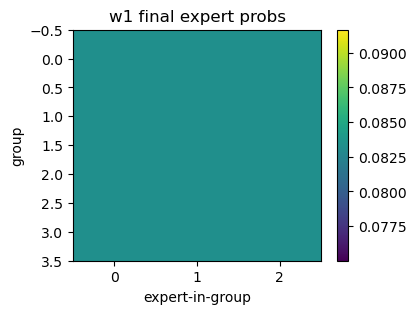

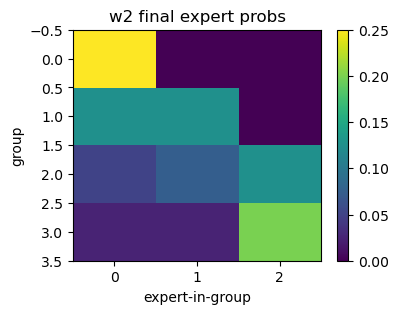

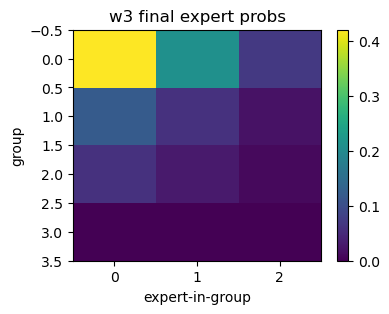

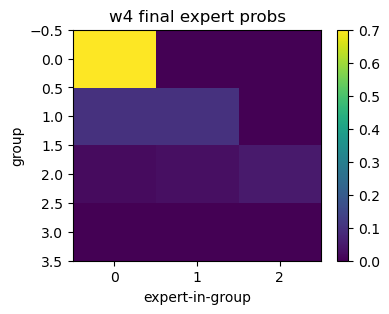

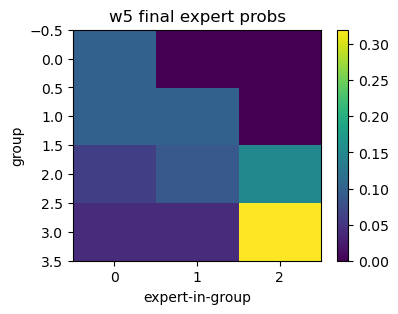

In [7]:
# wrapper 결과 시각화(heatmap)
def show_heatmap(vec, title):
    mat = vec.reshape(G, C).detach().cpu()
    plt.figure(figsize=(4, 3))
    plt.imshow(mat, aspect='auto')
    plt.title(title)
    plt.xlabel('expert-in-group')
    plt.ylabel('group')
    plt.colorbar()
    plt.show()

for name, wrapper in wrappers.items():
    out = wrapper(
        primitives=primitives,
        stage_temperature=1.0,
        n_groups=G,
        n_experts_per_group=C,
        params={'alpha_d': 1.0},
    )
    probs = torch.softmax(out['scaled_logits'], dim=-1)[0, 0]
    show_heatmap(probs, f'{name} final expert probs')

In [8]:
# N3StageBlock 스모크 테스트용 config helper
def default_stage_primitives(d_top_k=0):
    return {
        'a_joint': {'source': 'both', 'temperature': 1.0, 'top_k': 0},
        'b_group': {'source': 'both', 'temperature': 1.0, 'top_k': 0},
        'c_shared': {'source': 'both', 'temperature': 1.0, 'top_k': 0},
        'd_cond': {'source': 'feature', 'temperature': 1.0, 'top_k': d_top_k},
        'e_scalar': {'source': 'feature', 'temperature': 1.0, 'top_k': 0},
        'wrapper': {'alpha_d': 1.0},
    }

def build_mid_cfg(wrapper='w1_flat', d_top_k=0, expert_scale=3):
    spec = build_stage_feature_spec(macro_history_window=5, stage_feature_family_mask={})
    col2idx = build_column_to_index(ALL_FEATURE_COLUMNS)
    mid_features = [name for name in spec['stage_all_features']['mid'] if name in col2idx]
    return StageRuntimeConfigN3(
        stage_name='mid',
        d_model=16,
        d_ff=32,
        d_feat_emb=8,
        d_expert_hidden=24,
        d_router_hidden=12,
        expert_depth=1,
        expert_scale=expert_scale,
        top_k=0,
        dropout=0.0,
        attn_dropout=0.0,
        hidden_act='gelu',
        layer_norm_eps=1e-12,
        stage_feature_indices=tuple(int(col2idx[name]) for name in mid_features),
        stage_feature_names=tuple(mid_features),
        stage_family_features=spec['stage_family_features']['mid'],
        stage_feature_encoder_mode='linear',
        stage_compute_mode='moe',
        stage_router_mode='learned',
        stage_router_source='both',
        stage_feature_injection='none',
        routing_granularity='token',
        session_pooling='mean',
        rule_router_cfg={'variant': 'ratio_bins', 'n_bins': 5, 'feature_per_expert': 4},
        rule_bias_scale=0.0,
        feature_group_bias_lambda=0.0,
        feature_group_prior_temperature=1.0,
        stage_router_wrapper=wrapper,
        stage_router_primitives=default_stage_primitives(d_top_k=d_top_k),
        router_temperature=1.0,
        dense_hidden_scale=1.0,
        stage_residual_mode='base',
        residual_alpha_fixed=0.5,
        residual_alpha_init=0.0,
        shared_ffn_scale=1.0,
    )

In [9]:
# wrapper별 stage forward 테스트
torch.manual_seed(2026)
hidden = torch.randn(2, 5, 16)
feat = torch.randn(2, 5, len(ALL_FEATURE_COLUMNS))
item_seq_len = torch.tensor([5, 4], dtype=torch.long)

for wrapper in ['w1_flat', 'w2_a_plus_d', 'w3_bxc', 'w4_bxd', 'w5_exd']:
    cfg = build_mid_cfg(wrapper=wrapper, d_top_k=0, expert_scale=3)
    stage = N3StageBlock(cfg)
    next_hidden, gate_w, gate_l, router_aux, _ = stage(hidden, feat, item_seq_len=item_seq_len)
    print(wrapper,
          'next_hidden', tuple(next_hidden.shape),
          'gate_w', tuple(gate_w.shape),
          'sum_err', float((gate_w.sum(-1)-1).abs().max()),
          'has_aux', 'primitive_outputs' in router_aux)

w1_flat next_hidden (2, 5, 16) gate_w (2, 5, 12) sum_err 1.1920928955078125e-07 has_aux True
w2_a_plus_d next_hidden (2, 5, 16) gate_w (2, 5, 12) sum_err 1.7881393432617188e-07 has_aux True
w3_bxc next_hidden (2, 5, 16) gate_w (2, 5, 12) sum_err 1.1920928955078125e-07 has_aux True
w4_bxd next_hidden (2, 5, 16) gate_w (2, 5, 12) sum_err 1.1920928955078125e-07 has_aux True
w5_exd next_hidden (2, 5, 16) gate_w (2, 5, 12) sum_err 1.1920928955078125e-07 has_aux True


In [10]:
# W5 + D(top_k=1) => group당 1개, 총 4개 active 확인
torch.manual_seed(2027)
cfg = build_mid_cfg(wrapper='w5_exd', d_top_k=1, expert_scale=3)
stage = N3StageBlock(cfg)

hidden = torch.randn(2, 6, 16)
feat = torch.randn(2, 6, len(ALL_FEATURE_COLUMNS))
item_seq_len = torch.tensor([6, 5], dtype=torch.long)

_, gate_w, _, _, _ = stage(hidden, feat, item_seq_len=item_seq_len)
active = (gate_w > 0).sum(dim=-1)
print('active expert count min/max =', int(active.min()), int(active.max()))

active expert count min/max = 4 4
